# Evaluation on benchmark datasets

In this notebook, we will process and plot our results for the MMLU, GSM8K, and HumanEval datasets.

In [ ]:
# importing necessary libraries
import pandas as pd
import numpy as np
import os 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
%cd ../
from src.benchmark_datasets import DATASET
from src.utils import metric_per_query, error_vs_samples, get_max_gain, eval_generated_code

## Setup plot params

In [2]:
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amsfonts,geometry, bm}'
mpl.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams.update({
    'font.family':'serif',
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "font.size": 45,
    "figure.figsize":(13,8),
    "lines.markersize": 20,
    "axes.spines.top": False,
    "axes.spines.right": False
})

## MMLU

### Read and post process results

In [21]:
model_family = "llama" # choose between "llama", "mistral", "qwen"
expl_results = pd.read_csv(f"outputs/mmlu/{model_family}/results.csv", index_col='Noise').map(lambda x: 1 if x == True else (0 if x == False else x))

### Covariance 

In [ ]:
def plot_cov(task, models, expl_results, save=False, model_family='llama', save_path='figures'):
    expl_results_task = expl_results[expl_results['Subject'] == task] 
    to_cov = expl_results_task.drop(expl_results_task.index[len(expl_results_task)//2:]).reset_index(inplace=False).drop(['Noise', 'Subject'], axis=1)
    query_id = [i  for i in range(len(to_cov)//10) for _ in range(10)]
    to_cov['Qid'] = query_id
    to_cov.set_index('Qid', inplace=True)
    # for all pairs of models
    for i, model_a in enumerate(models):
        for j, model_b in enumerate(models):
            if i >= j:
                continue
            # compute the covariance matrix per model pair
            cov_matrix = to_cov[[model_a, model_b]].groupby('Qid').cov()
            if cov_matrix.iloc[1].name != model_b and 'llama' not in model_family:
                # get the covariance per pair   
                cov_matrix = cov_matrix.iloc[1::2][model_b].droplevel(1, axis=0).rename((model_a, model_b))
            else:
                # get the covariance per pair   
                cov_matrix = cov_matrix.iloc[::2][model_b].droplevel(1, axis=0).rename((model_a, model_b))
            
            # kde plot with fill
            ax = sns.kdeplot(cov_matrix.values, fill=True, color='teal')
            # kde plot without fill
            sns.kdeplot(cov_matrix.values, fill=False, color='teal', ax=ax)
            # get the y and x values for the mean
            x_values, y_values = ax.lines[0].get_data()
            # add vertical line for the mean
            mean = cov_matrix.mean()
            mean_y = y_values[np.abs(x_values - mean).argmin()]
            plt.vlines(mean,ymin=0, ymax=mean_y, color='teal', linestyle='--', lw=3)
            
            ax.set_xlabel("Covariance (coupled)")
            ax.set_xticks([-0.1, 0, 0.1, 0.2, 0.3])
            ax.set_yticks([0, 2, 4, 6])
            
            if save:
                fig_path = f'./{save_path}/mmlu/{model_family}/{task}/covariance'
                if not os.path.exists(fig_path):
                    os.makedirs(fig_path)
                plt.savefig(f"{fig_path}/cov_{model_a}_{model_b}_kde.pdf", bbox_inches='tight')
            else: 
                print(model_a, model_b)
                plt.show()
            plt.clf()

Llama-3.2-1B-Instruct Llama-3.2-3B-Instruct


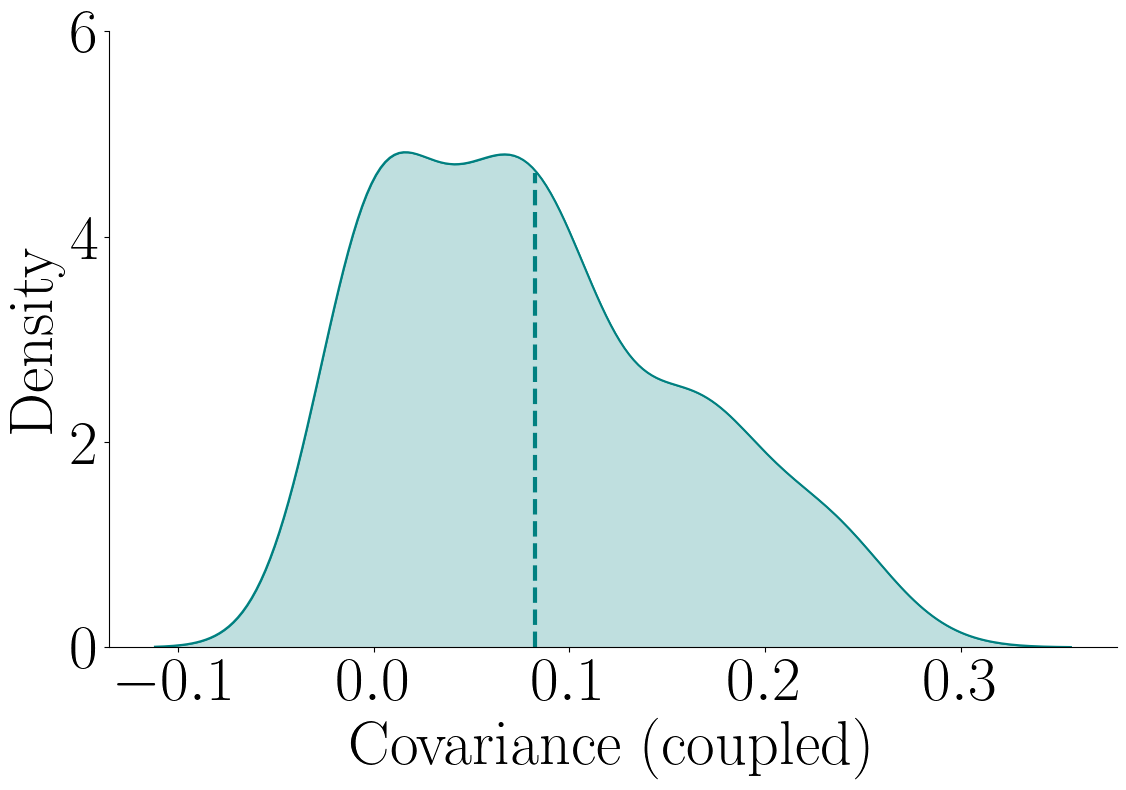

<Figure size 1300x800 with 0 Axes>

In [22]:
# covariance kde plots for a pair of models 
models = ('Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct')# model names
task = 'college_computer_science'
plot_cov(task, models, expl_results, save=False, model_family=model_family)

In [ ]:
# covariance kde plots for all areas in mmlu and all pairs of models for the chosen model family
# figures saved under 'figures/mmlu/{model_family}/{task}/covariance'
models = expl_results.columns[:-1].values
for task in subjects.unique():
    plot_cov(task, models, expl_results, save=True, model_family=model_family)
    

### Variance of the score difference 

In [13]:
def plot_var(pivoted, model_a, model_b, task, save=False, model_family='llama', save_path='figures'):
    # fix model order 
    if (model_a, model_b, 'Coupled') not in pivoted.columns:
        model_a, model_b = model_b, model_a

    # kde plot with median point
    x = (model_a, model_b, 'Coupled')
    y = (model_a, model_b, 'Independent')
    ax = sns.kdeplot(x=pivoted[x], y=pivoted[y], fill=True, color='teal')
    median_x = pivoted[(model_a, model_b, 'Coupled')].median()
    median_y = pivoted[(model_a, model_b, 'Independent')].median()
    ax.scatter(median_x, median_y,  label='Median', c='darkslategray', marker='H')
    ax.set_xlabel("Variance (coupled)")
    ax.set_ylabel("Variance (independent)")

    # plot the identity line
    xpoints = ax.get_xlim()
    ax_dig = ax.plot(xpoints, xpoints, linestyle='--', color='k')

    # add text annotation parallel to the identity line
    eps =  xpoints[-1]/100
    scale = 1.8
    dx = xpoints[-1] - xpoints[-2]
    angle = np.rad2deg(np.arctan2(dx, dx))
    ax.text(xpoints[-1] - scale * eps, xpoints[-1] + scale * eps, "y=x", fontsize=35, transform_rotates_text=True, rotation=angle, rotation_mode='anchor', ha='right', va='bottom')
    
    if save:
        fig_path = f'./{save_path}/mmlu/{model_family}/{task}/variance'
        if not os.path.exists(fig_path):
            os.makedirs(fig_path)
        plt.savefig(f"{fig_path}/var_{model_a}_{model_b}_kde.pdf", bbox_inches='tight')
    else:
        print(task)
        print(model_a, model_b)
        plt.show()
    plt.clf()


college_computer_science
Llama-3.2-3B-Instruct Llama-3.2-1B-Instruct


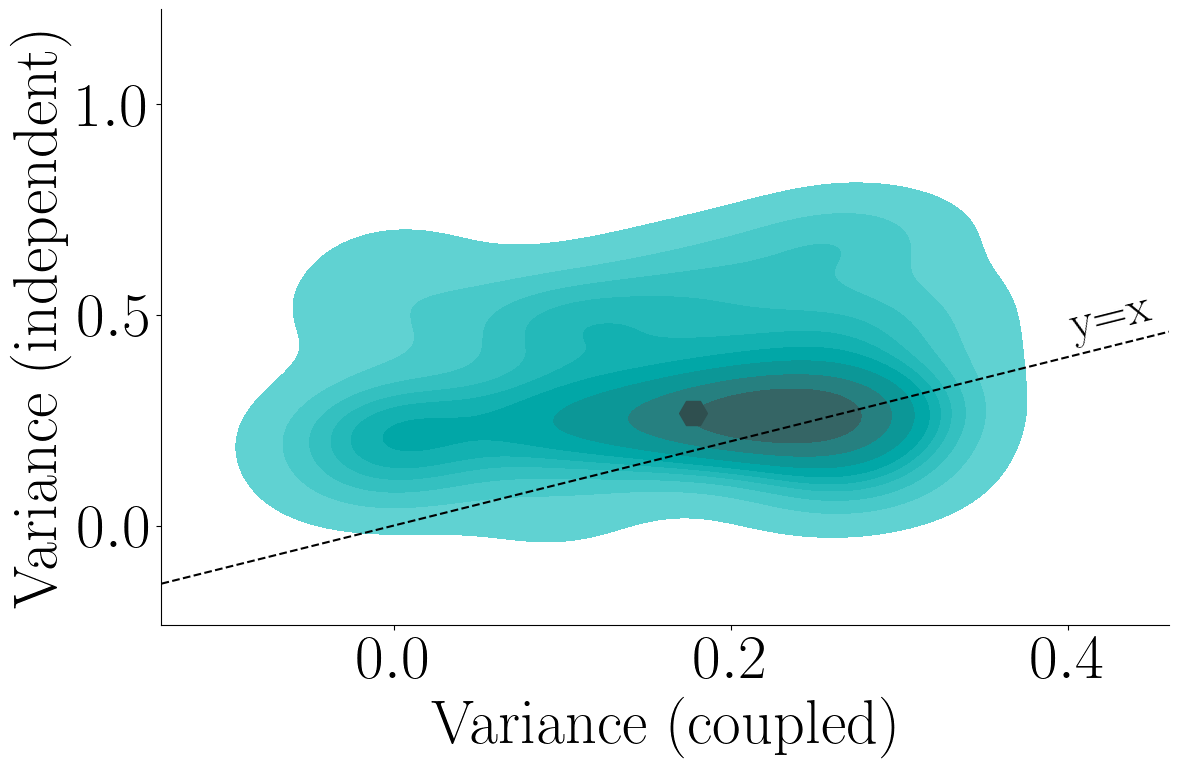

<Figure size 1300x800 with 0 Axes>

In [24]:
# variance kde for a single pair of models and given area (task) 
task = 'college_computer_science'
model_a = 'Llama-3.2-3B-Instruct'
model_b = 'Llama-3.2-1B-Instruct'
piv =  metric_per_query(task, expl_results, metric='var')
plot_var(piv, model_a, model_b, task, save=False, model_family=model_family)

In [ ]:
# kde plots for several areas and all pairs of models for the chosen model family
# figures saved under 'figures/mmlu/{model_family}/{task}/variance'
tasks = [ 'college_computer_science', 'college_chemistry', 'professional_law', 'professional_accounting', 'professional_medicine']
for task in tasks:
    piv = metric_per_query(task, expl_results, metric='var')
    for i in range(1, len(piv.columns), 2): 
        model_a = piv.columns[i][0]
        model_b = piv.columns[i][1]     
        plot_var(piv, model_a, model_b, task, save=True, model_family=model_family)

### Estimation error vs # samples

In [14]:
def plot_error(pair, pair_df, err, n_samples_coupled, n_samples_ind, ds_name='gsm8k', show_zoom=True, save=True, scale=1, align_anot_threshold=0.1, save_path='figures'):

    # rename the column to be the pair
    col_name = f"Estimation Error"
    pair_df.columns = [col_name]

    # create custom palette
    palette = sns.color_palette(['teal', 'palevioletred'], 2)
    sns.set_palette(palette)

    ax = sns.lineplot(pair_df, x='Samples', y=col_name, markers=True, style='Noise', hue='Noise', errorbar=('ci',95))

    # set the marker edgecolor to be the same as the facecolor
    for line in ax.get_lines():
        line.set_markeredgewidth(0)
        line.set_markersize(8)

    ax.set_xlabel('Number of Samples')
  
    # place the legend on top of the plot in a single line
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
    # remove frame from legend
    ax.get_legend().get_frame().set_linewidth(0.0)
    ax.get_legend().get_frame().set_alpha(None)
    ax.set_xscale('log')
    ax.set_aspect('auto')

    # show zoomed block only if the gain is >=10%
    if show_zoom:
        # create zoomed in region
        axins = ax.inset_axes([0.5, 0.6, 0.4, 0.4])
        ax_of_axins = sns.lineplot(pair_df, x='Samples', y=col_name, markers=True, style='Noise', hue='Noise', errorbar=('ci',95), ax=axins,  legend=False)
        for line in ax_of_axins.get_lines():
            line.set_markeredgewidth(0)
            line.set_markersize(8)
        ax_of_axins.set_xlabel('')
        ax_of_axins.set_ylabel('')

        x1 = int(np.ceil(n_samples_coupled * (1 - scale * 0.1)))
        x2 = int(np.ceil(n_samples_ind * (1 + scale * 0.1)))
        y1, y2 = err * (1 - scale * 0.1), err * (1 + scale * 0.1)

        # add vertical and horizontal lines
        ax_of_axins.axhline(y=err, color='gray', linestyle='--')
        ax_of_axins.axvline(x=n_samples_coupled, ymax=(err - y1)/(y2-y1), color='gray', linestyle='--')
        ax_of_axins.axvline(x=n_samples_ind, ymax=(err - y1)/(y2-y1), color='gray', linestyle='--')
        ax_of_axins.set_xticks([n_samples_coupled, n_samples_ind])
        # align the tick labels so that they do not overlap
        if (n_samples_coupled - n_samples_ind) / (x2 - x1) <= align_anot_threshold:
            ax_of_axins.get_xaxis().majorTicks[0].label1.set_horizontalalignment('right')
            ax_of_axins.get_xaxis().majorTicks[1].label1.set_horizontalalignment('left')
        

        ax_of_axins.set_yticks([err])
        ax_of_axins.spines[['top', 'right']].set_visible(False)

        # original subregion
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        axins.set_aspect('auto')
        ax.indicate_inset_zoom(axins)

    if save:
        fig_path = f'./{save_path}/{ds_name}/error/'
        if not os.path.exists(fig_path):
            os.makedirs(fig_path)
        plt.savefig(f"{fig_path}/error_{pair[0]}_{pair[1]}.pdf", bbox_inches='tight')
    else:
        plt.show()
    plt.clf()


  0%|          | 0/49000 [00:00<?, ?it/s]


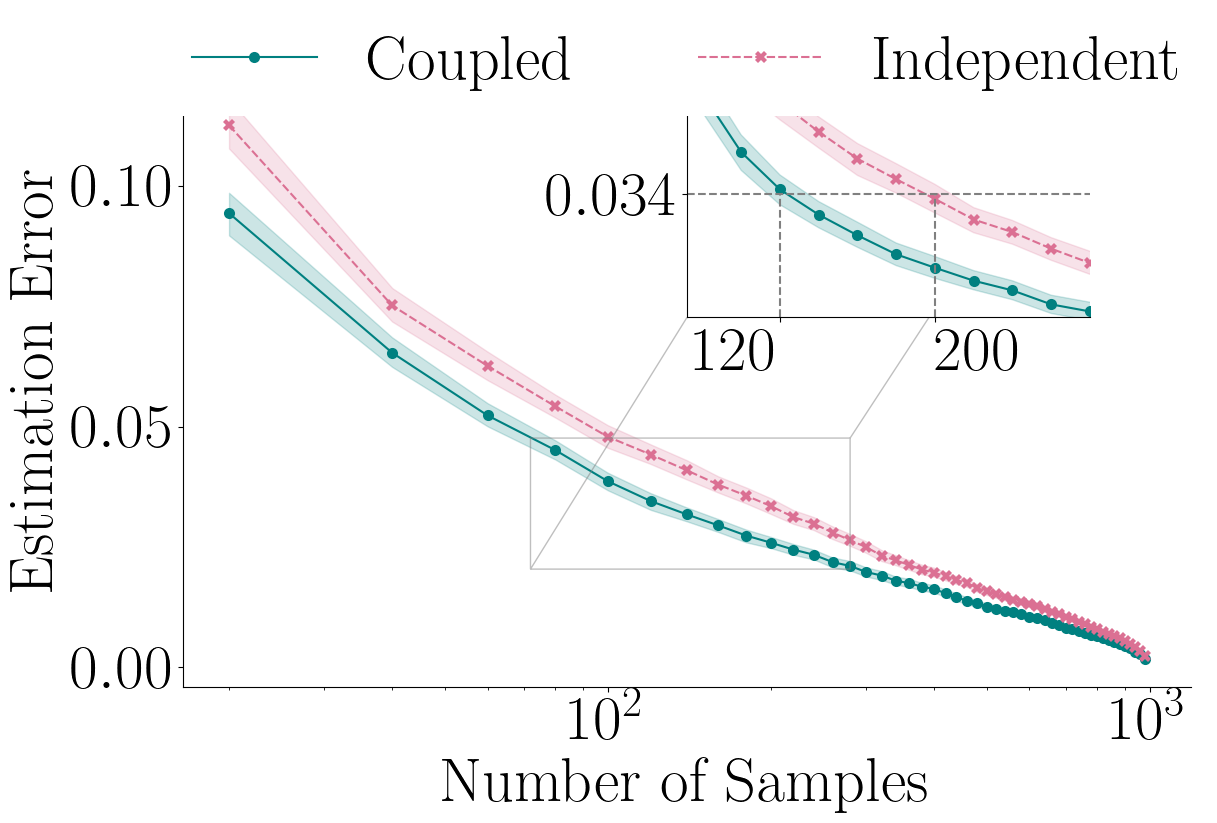

<Figure size 1300x800 with 0 Axes>

In [26]:
# estimation error vs number of samples for a single task and model pair
task = 'college_computer_science'
error = error_vs_samples(task, expl_results)
model_a = 'Llama-3.2-3B-Instruct'
model_b = 'Llama-3.2-1B-Instruct'
pair = (model_a, model_b) if (model_a, model_b) in error.columns else (model_b, model_a)
pair_df = error[pair].to_frame()

threshold = 0.05 # threshold factor controlling the relative error similarity window   
gain, err, n_samples_coupled, n_samples_ind = get_max_gain(pair_df, threshold=threshold)
show_zoom = gain >= 0.1    
plot_error(pair, pair_df, err, n_samples_coupled, n_samples_ind, show_zoom=show_zoom, ds_name=f'mmlu/{model_family}/college_computer_science', scale=4, save=False)

In [ ]:
# estimation error vs number of samples different tasks and all model pairs
# figures saved under 'figures/mmlu/{model_family}/{task}/error'
tasks = [ 'college_chemistry', 'professional_law', 'professional_accounting', 'professional_medicine']
for task in tasks:
    error = error_vs_samples(task, expl_results)

    for i in range(len(error.columns)):
        pair = error.columns[i]
        pair_df = error[pair].to_frame()
        
        # adjust the threshold factor based on the error scale (depends on the pair of models)
        if (pair == ('Llama-3.1-8B-Instruct-bnb-8bit', 'Llama-3.1-8B-Instruct')) or (len(pair[0]) == len(pair[1]) and len(pair[0]) == 21):
            threshold = 0.05
        elif model_family == 'llama':
            threshold = 0.005
        else:
            threshold = 0.01
        gain, err, n_samples_coupled, n_samples_ind = get_max_gain(pair_df, threshold=threshold)
        show_zoom = gain >= 0.1    
        plot_error(pair, pair_df, err, n_samples_coupled, n_samples_ind, show_zoom=show_zoom, ds_name=f'mmlu/{model_family}/{task}', scale=4)
        

### Results for other temperatures and top-p sampling

In [ ]:
sampling_confs = ['temperature_0.5', 'temperature_0.9', 'temperature_0.7_p_0.9']
task = 'college_computer_science'

for sampling_conf in sampling_confs:
    path = f"outputs/mmlu/llama/temperature_top_p/{sampling_conf}/"
    figure_path = f"figures/{sampling_conf}"
    
    expl_results = pd.read_csv(f"{path}/results.csv", index_col='Noise').map(lambda x: 1 if x == True else (0 if x == False else x))

    # Covariance 
    models = ('Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct')# model names
    plot_cov(task, models, expl_results, save=True, model_family=model_family, save_path=figure_path)

    # variance kde for a single pair of models and given area (task) 
    piv =  metric_per_query(task, expl_results, metric='var')
    model_a = 'Llama-3.2-3B-Instruct'
    model_b = 'Llama-3.2-1B-Instruct'
    plot_var(piv, model_a, model_b, task, save=True, model_family=model_family, save_path=figure_path)

    # estimation error vs number of samples for a single task and model pair
    error = error_vs_samples(task, expl_results)
    model_a = 'Llama-3.2-3B-Instruct'
    model_b = 'Llama-3.2-1B-Instruct'
    pair = (model_a, model_b) if (model_a, model_b) in error.columns else (model_b, model_a)
    pair_df = error[pair].to_frame()

    threshold = 0.05 # threshold factor controlling the relative error similarity window   
    gain, err, n_samples_coupled, n_samples_ind = get_max_gain(pair_df, threshold=threshold)
    print(f"Sampling configuration {sampling_conf}, gain {gain}")
    show_zoom = gain >= 0.1    
    plot_error(pair, pair_df, err, n_samples_coupled, n_samples_ind, show_zoom=show_zoom, ds_name=f'mmlu/{model_family}/college_computer_science', scale=4, save=True, save_path=figure_path)


## GSM8K

### Read and post process results

In [29]:
model_family = "mistral" # choose between "llama", "mistral", "qwen"
expl_results = pd.read_csv(f"outputs/gsm8k/{model_family}/results.csv", index_col='Noise').map(lambda x: 1 if x == True else (0 if x == False else x))

### Covariance 

In [30]:
def plot_cov_kde(models, expl_results, save=False, res_root='gsm8k', model_family='llama'):
    """Plot the covariance kde plot"""
    to_cov = expl_results.drop(expl_results.index[len(expl_results)//2:]).reset_index(inplace=False).drop(['Noise'], axis=1)
    query_id = [i  for i in range(len(to_cov)//10) for _ in range(10)]
    to_cov['Qid'] = query_id
    to_cov.set_index('Qid', inplace=True)
    for i, model_a in enumerate(models):
        for j, model_b in enumerate(models):
            if i >= j:
                continue
            cov_matrix = to_cov[[model_a, model_b]].groupby('Qid').cov()
            # drop the even rows
            if cov_matrix.iloc[1].name != model_b:
                # get the covariance per pair   
                cov_matrix = cov_matrix.iloc[1::2][model_b].droplevel(1, axis=0).rename((model_a, model_b))
            else:
                # get the covariance per pair   
                cov_matrix = cov_matrix.iloc[::2][model_b].droplevel(1, axis=0).rename((model_a, model_b))
            
        
            ax = sns.kdeplot(
                cov_matrix.values, 
                fill=True, 
                color='teal'
                )
            sns.kdeplot(cov_matrix.values, fill=False, color='teal', ax=ax)
            # get the y of the kde plot for the x value of the mean
            x_values, y_values = ax.lines[0].get_data()
            # add vertical line for the mean
            mean = cov_matrix.mean()
            mean_y = y_values[np.abs(x_values - mean).argmin()]
            plt.vlines(mean,ymin=0, ymax=mean_y, color='teal', linestyle='--', lw=3)
            
            ax.set_xlabel("Covariance (coupled)")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            if save:
                fig_path = f'./figures/{res_root}/{model_family}/covariance'
                if not os.path.exists(fig_path):
                    os.makedirs(fig_path)
                plt.savefig(f"{fig_path}/cov_{model_a}_{model_b}_kde.pdf", bbox_inches='tight')
            else: 
                plt.show()
            plt.clf()

In [ ]:
# plot and save the covariance kde plot for all pairs of models for the chosen model family
# figures saved under ./figures/gsm8k/{model_family}/covariance
models = expl_results.columns.values
plot_cov_kde(models, expl_results, save=True, model_family=model_family)

### Variance of the score difference 

In [32]:
def plot_var(pivoted, model_a, model_b, save=False, res_root='gsm8k', model_family='llama'):
    # fix model order 
    if (model_a, model_b, 'Coupled') not in pivoted.columns:
        model_a, model_b = model_b, model_a

    # kde plot with median point
    x = (model_a, model_b, 'Coupled')
    y = (model_a, model_b, 'Independent')
    ax = sns.kdeplot(x=pivoted[x], y=pivoted[y], fill=True, color='teal')
    median_x = pivoted[(model_a, model_b, 'Coupled')].median()
    median_y = pivoted[(model_a, model_b, 'Independent')].median()
    ax.scatter(median_x, median_y,  label='Median', c='darkslategray', marker='H')
    ax.set_xlabel("Variance (coupled)")
    ax.set_ylabel("Variance (independent)")

    # plot the identity line
    xpoints = ax.get_xlim()
    ax_dig = ax.plot(xpoints, xpoints, linestyle='--', color='k')
    # add text annotation parallel to the identity line
    eps =  xpoints[-1]/100
    scale = 1.8
    dx = xpoints[-1] - xpoints[-2]
    angle = np.rad2deg(np.arctan2(dx, dx))
    ax.text(xpoints[-1] - scale * eps, xpoints[-1] + scale * eps, "y=x", fontsize=35, transform_rotates_text=True, rotation=angle, rotation_mode='anchor', ha='right', va='bottom')
  
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if save:
        fig_path = f'./figures/{res_root}/{model_family}/variance'
        if not os.path.exists(fig_path):
            os.makedirs(fig_path)
        plt.savefig(f"{fig_path}/var_{model_a}_{model_b}_kde.pdf", bbox_inches='tight')
    else:
        print(model_a, model_b)
        plt.show()
    plt.clf()

In [ ]:
# plot and save variance kde for all pairs of models for the chosen model family
# figures saved under ./figures/gsm8k/{model_family}/variance
piv =  metric_per_query(None, expl_results, metric='var')
for i in range(1, len(piv.columns), 2): 
    model_a = piv.columns[i][0]
    model_b = piv.columns[i][1]
    plot_var(piv, model_a, model_b, save=True, model_family=model_family)

### Estimation error vs # samples

In [ ]:
# plot and save estimation error vs number of samples for all model pairs (this takes a while... ~40mins)
# figures saved under ./figures/gsm8k/{model_family}/error
error = error_vs_samples(None, expl_results)
n_pairs_positive_gain = 0
for i in range(len(error.columns)):
    pair = error.columns[i]
    pair_df = error[pair].to_frame()
    gain, err, n_samples_coupled, n_samples_ind = get_max_gain(pair_df, keep_middle=False)
    show_zoom = gain >= 0.1    
    plot_error(pair, pair_df, err, n_samples_coupled, n_samples_ind, show_zoom=show_zoom, ds_name=f"gsm8k/{model_family}", save=True, align_anot_threshold=-100)

## HumanEval

### Code evaluation

In [ ]:
# This can take several minutes (e.g. 10-15mins) to run depending on the number of models of the model family 
from datasets import load_dataset
#  create the 'problem' jsonl file as instructed in the evaluation harness (this is necessary for the code evaluation later)
ds_conf = DATASET['human_eval']
data_cache_dir = 'data/original'
dataset = load_dataset(ds_conf['dataset_path'], name=ds_conf['name'], split='test', cache_dir=data_cache_dir)
dataset.set_format(type='pandas')
ds = dataset[0:][['task_id', 'prompt', 'canonical_solution', 'test', 'entry_point']]
path = 'data/processed'
ds.to_json(f'{path}/human_eval_problem.jsonl', orient='records', lines=True)

# create the jsonl file with the correctness of each code solution
# NOTE: the code below runs only upon successful completion of the installation instructions in the public repo https://github.com/openai/human-eval 
model_family = 'qwen' # select the model family to be one of 'llama', 'mistral' or 'qwen'
results_path_root = f"./outputs/human_eval/{model_family}"
eval_generated_code(results_path_root, ds_conf, data_cache_dir)



### Read and post process results

In [36]:
model_family = "qwen" # choose between "llama", "mistral", "qwen"
expl_results = pd.read_csv(f"outputs/human_eval/{model_family}/results.csv", index_col='Noise').map(lambda x: 1 if x == True else (0 if x == False else x))

### Covariance

In [ ]:
# plot the covariance kde plot for all pairs of models
# figures saved under ./figures/human_eval/{model_family}/covariance
models = expl_results.columns.values
plot_cov_kde(models, expl_results, save=True, res_root='human_eval', model_family=model_family)

### Variance of the score difference 

In [ ]:
# variance kde for all pairs of models 
# figures saved under ./figures/human_eval/{model_family}/variance
piv =  metric_per_query(None, expl_results, metric='var')
for i in range(1, len(piv.columns), 2): 
    model_a = piv.columns[i][0]
    model_b = piv.columns[i][1]
    plot_var(piv, model_a, model_b, save=True, res_root='human_eval', model_family=model_family)

### Estimation error vs # samples

In [ ]:
# estimation error vs number of samples for all model pairs
# figures saved under ./figures/human_eval/{model_family}/error
error = error_vs_samples(None, expl_results)
for i in range(len(error.columns)):
    pair = error.columns[i]
    pair_df = error[pair].to_frame()
    gain, err, n_samples_coupled, n_samples_ind = get_max_gain(pair_df, keep_middle=False)
    show_zoom = gain >= 0.1    
    plot_error(pair, pair_df, err, n_samples_coupled, n_samples_ind, show_zoom=show_zoom, ds_name=f'human_eval/{model_family}', align_anot_threshold=-1)